# Environment

## Imports

In [1]:
import os
import time
import warnings
import scanpy as sc
import numpy as np
from scipy.linalg import orthogonal_procrustes
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## Global variables

In [2]:
warnings.filterwarnings("ignore")

## Load the data

In [3]:
adata_rapids = sc.read_h5ad(
    os.path.join("results", "pbmc10k_rapids.h5ad"),
)
adata_rapids

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo', 'leiden'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_pca_covariance_eigh_0', 'X_pca_covariance_eigh_1', 'X_pca_covariance_eigh_2', 'X_pca_lanczos_0', 'X_pca_lanczos_1', 'X_pca_lanczos_2', 'X_pca_randomized_0', 'X_pca_randomized_1', 'X_pca_randomized_2', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'neighbors0_all_neighbors', 'neighbors0_brute', 'neighbors0_cagra', 'neighbors0_ivfflat', 'neighbors0_ivfpq', 'neighbors0_nn_descent', 'neighbors1_all_neighbors', 'neigh

In [4]:
adata_scanpy = sc.read_h5ad(
    os.path.join("results", "pbmc10k_scanpy.h5ad"),
)
adata_scanpy

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden_igraph', 'leiden_leidenalg'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_pca_arpack_0', 'X_pca_arpack_1', 'X_pca_arpack_2', 'X_pca_covariance_eigh_0', 'X_pca_covariance_eigh_1', 'X_pca_covariance_eigh_2', 'X_pca_randomized_0', 'X_pca_randomized_1', 'X_pca_randomized_2', 'hvg', 'leiden_igraph', 'leiden_igraph_colors', 'leiden_leidenalg', 'leiden_leidenalg_colo

# Compare

## QC

Check that we have the same set of cells and genes in both datasets

In [5]:
assert adata_rapids.shape == adata_scanpy.shape, "Shapes do not match"
assert all(adata_rapids.obs_names == adata_scanpy.obs_names), "Cell names do not match"
assert all(adata_rapids.var_names == adata_scanpy.var_names), "Gene names do not match"

Check that values are the same in both datasets

In [6]:
columns = [
    "n_genes_by_counts",
    "log1p_n_genes_by_counts",
    "total_counts",
    "log1p_total_counts",
    "total_counts_mt",
    "log1p_total_counts_mt",
    "pct_counts_mt",
    "total_counts_ribo",
    "log1p_total_counts_ribo",
    "pct_counts_ribo",
]

assert np.allclose(
    adata_rapids.obs[columns].values,
    adata_scanpy.obs[columns].values,
    rtol=1e-5,
    atol=1e-8,
), "QC metrics do not match"

## Normalization

Check that processed data is the same in both datasets

In [7]:
A = adata_rapids.X.tocsr()
B = adata_scanpy.X.tocsr()
D = (A - B).tocsr()
rows, cols = D.nonzero()
b_vals = B[rows, cols].A1
ok = np.all(np.abs(D.data) <= (1e-8 + 1e-5 * np.abs(b_vals)))
assert ok and A.shape == B.shape, "Processed matrices do not match"

Check highly variable genes lists

In [8]:
assert np.all(
    adata_rapids.var["highly_variable"].values
    == adata_scanpy.var["highly_variable"].values
), "Highly variable genes do not match"

## PCA

To compare PCA embeddings, we need to account for the fact that they are only defined up to an orthogonal transformation. We can find the optimal rotation to align the embeddings and then compute the correlation between the columns of the rotated embeddings.

Let's start with PCA embeddings generated by `single-cell-rapids`. Let's calculate the following metrics:
- maximum absolute correlation deviation for PCA components
- relative Frobenius norm of the difference between the aligned PCA embeddings
- whether the aligned PCA embeddings are approximately equal (using `np.allclose` with some tolerance)

In [9]:
pca_corr = lambda A, B: np.array(
    [np.corrcoef(A[:, j], B[:, j])[0, 1] for j in range(A.shape[1])]
)

In [10]:
rapids_entries = [
    "X_pca_covariance_eigh_0",
    "X_pca_covariance_eigh_1",
    "X_pca_covariance_eigh_2",
    "X_pca_lanczos_0",
    "X_pca_lanczos_1",
    "X_pca_lanczos_2",
    "X_pca_randomized_0",
    "X_pca_randomized_1",
    "X_pca_randomized_2",
]

In [11]:
rapids_fro_result = []
rapids_corr_result = []
rapids_same_result = []
for entry_l in tqdm(rapids_entries):
    entry_fro_result = []
    entry_corr_result = []
    entry_same_result = []
    for entry_r in rapids_entries:
        # rotate matrix B to match A
        A = adata_rapids.obsm[entry_l]
        B = adata_rapids.obsm[entry_r]
        R, _ = orthogonal_procrustes(B, A)
        B_rot = B @ R
        # calculate metrics
        entry_corr_result.append(np.log10((1.0 - np.abs(pca_corr(A, B))).max()) + 1e-10)
        entry_fro_result.append(
            np.log10(
                np.linalg.norm(A - B_rot, ord="fro") / np.linalg.norm(A, ord="fro") + 1e-10
            )
        )
        entry_same_result.append(np.allclose(A, B_rot, rtol=1e-5, atol=1e-3))
    rapids_fro_result.append(entry_fro_result)
    rapids_corr_result.append(entry_corr_result)
    rapids_same_result.append(entry_same_result)

  0%|          | 0/9 [00:00<?, ?it/s]

Text(0.5, 0.98, 'Comparison of PCA embeddings generated by single-cell-rapids')

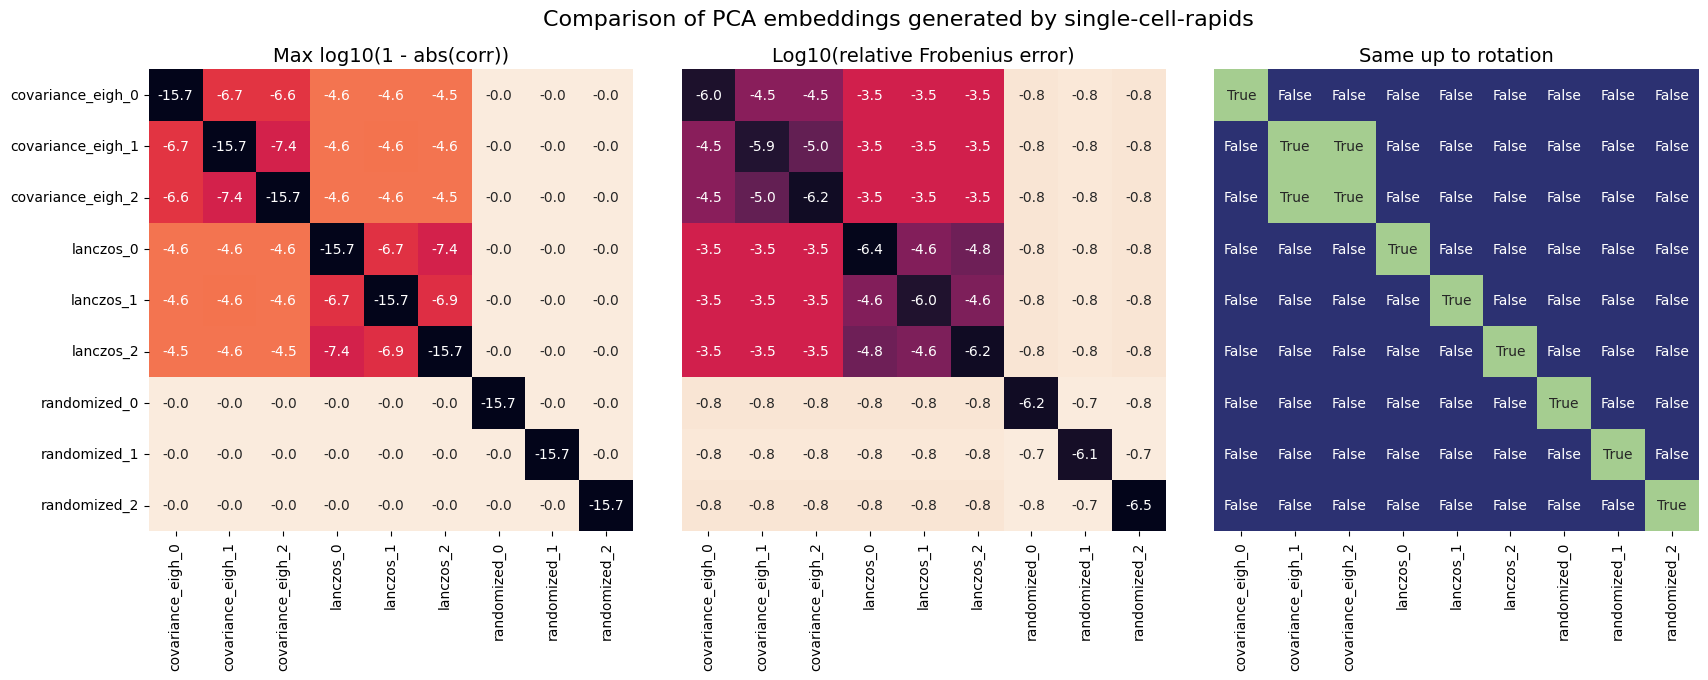

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"wspace": 0.1})

labels = [entry.replace("X_pca_", "") if entry != "X_pca" else "covariance_eigh_0" for entry in rapids_entries]
sns.heatmap(
    rapids_corr_result,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".1f",
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Max log10(1 - abs(corr))", fontsize=14)

sns.heatmap(
    rapids_fro_result,
    xticklabels=labels,
    yticklabels="",
    annot=True,
    fmt=".1f",
    cbar=False,
    ax=axes[1],
)
axes[1].set_title("Log10(relative Frobenius error)", fontsize=14)

sns.heatmap(
    rapids_same_result,
    xticklabels=labels,
    yticklabels="",
    annot=True,
    fmt="",
    ax=axes[2],
    cbar=False,
    cmap="crest_r",
)
axes[2].set_title("Same up to rotation", fontsize=14)
fig.suptitle("Comparison of PCA embeddings generated by single-cell-rapids", fontsize=16)

Now let's do the same for PCA embeddings generated by `scanpy`.

In [13]:
scanpy_entries = [
    "X_pca_covariance_eigh_0",
    "X_pca_covariance_eigh_1",
    "X_pca_covariance_eigh_2",
    "X_pca_arpack_0",
    "X_pca_arpack_1",
    "X_pca_arpack_2",
    "X_pca_randomized_0",
    "X_pca_randomized_1",
    "X_pca_randomized_2",
]

In [14]:
scanpy_fro_result = []
scanpy_corr_result = []
scanpy_same_result = []
for entry_l in tqdm(scanpy_entries):
    entry_fro_result = []
    entry_corr_result = []
    entry_same_result = []
    for entry_r in scanpy_entries:
        # rotate matrix B to match A
        A = adata_scanpy.obsm[entry_l]
        B = adata_scanpy.obsm[entry_r]
        R, _ = orthogonal_procrustes(B, A)
        B_rot = B @ R
        # calculate metrics
        entry_corr_result.append(np.log10((1.0 - np.abs(pca_corr(A, B))).max()) + 1e-10)
        entry_fro_result.append(
            np.log10(
                np.linalg.norm(A - B_rot, ord="fro") / np.linalg.norm(A, ord="fro")
                + 1e-10
            )
        )
        entry_same_result.append(np.allclose(A, B_rot, rtol=1e-5, atol=1e-3))
    scanpy_fro_result.append(entry_fro_result)
    scanpy_corr_result.append(entry_corr_result)
    scanpy_same_result.append(entry_same_result)

  0%|          | 0/9 [00:00<?, ?it/s]

Text(0.5, 0.98, 'Comparison of PCA embeddings generated by scanpy')

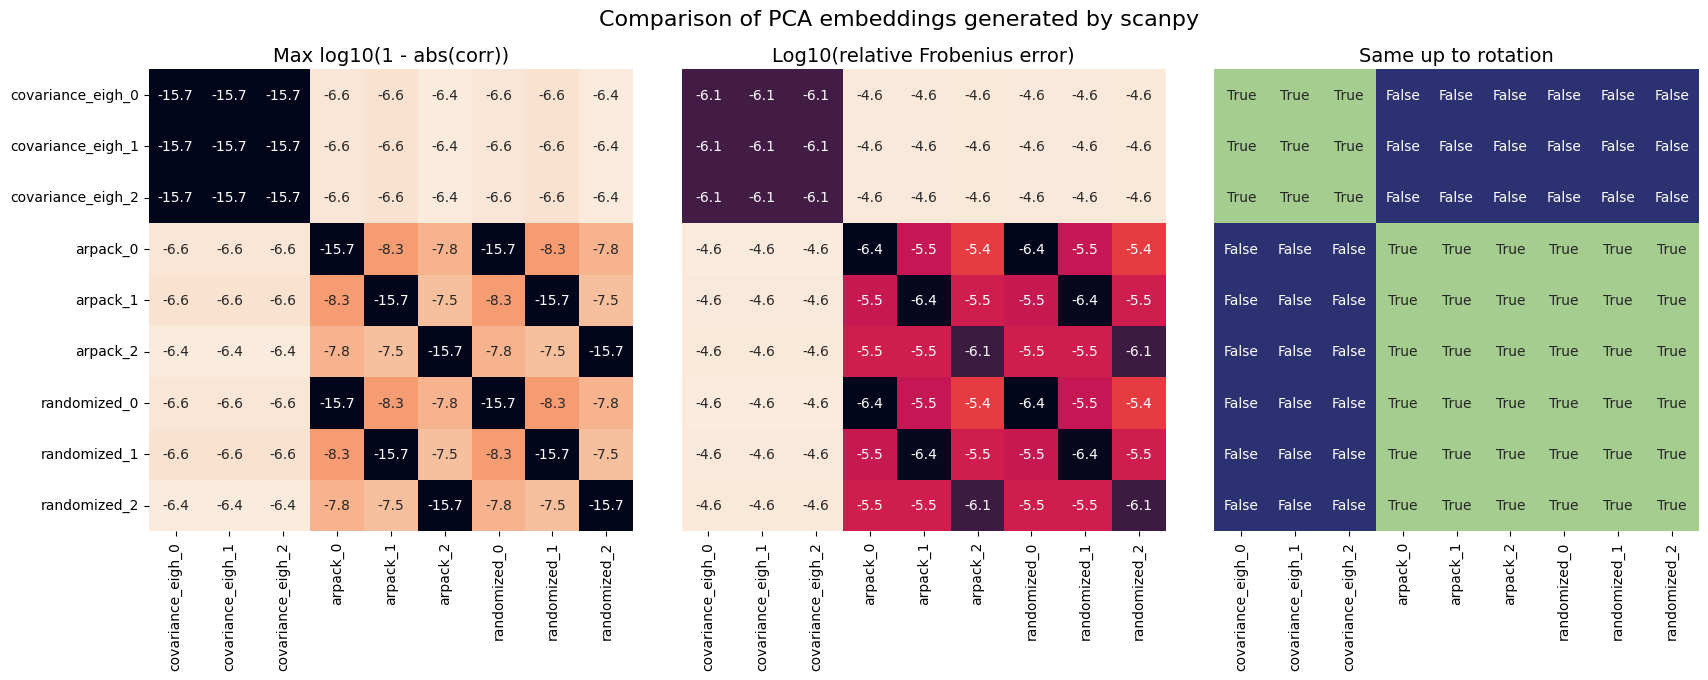

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"wspace": 0.1})

labels = [
    entry.replace("X_pca_", "") for entry in scanpy_entries
]
sns.heatmap(
    scanpy_corr_result,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".1f",
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Max log10(1 - abs(corr))", fontsize=14)

sns.heatmap(
    scanpy_fro_result,
    xticklabels=labels,
    yticklabels="",
    annot=True,
    fmt=".1f",
    cbar=False,
    ax=axes[1],
)
axes[1].set_title("Log10(relative Frobenius error)", fontsize=14)

sns.heatmap(
    scanpy_same_result,
    xticklabels=labels,
    yticklabels="",
    annot=True,
    fmt="",
    ax=axes[2],
    cbar=False,
    cmap="crest_r",
)
axes[2].set_title("Same up to rotation", fontsize=14)
fig.suptitle("Comparison of PCA embeddings generated by scanpy", fontsize=16)

Now compare PCA embeddings from `single-cell-rapids` and `scanpy` directly

In [16]:
rapids_scanpy_fro_result = []
rapids_scanpy_corr_result = []
rapids_scanpy_same_result = []
for entry_l in tqdm(rapids_entries):
    entry_fro_result = []
    entry_corr_result = []
    entry_same_result = []
    for entry_r in scanpy_entries:
        # rotate matrix B to match A
        A = adata_rapids.obsm[entry_l]
        B = adata_scanpy.obsm[entry_r]
        R, _ = orthogonal_procrustes(B, A)
        B_rot = B @ R
        # calculate metrics
        entry_corr_result.append(np.log10((1.0 - np.abs(pca_corr(A, B))).max()) + 1e-10)
        entry_fro_result.append(
            np.log10(
                np.linalg.norm(A - B_rot, ord="fro") / np.linalg.norm(A, ord="fro")
                + 1e-10
            )
        )
        entry_same_result.append(np.allclose(A, B_rot, rtol=1e-5, atol=1e-3))
    rapids_scanpy_fro_result.append(entry_fro_result)
    rapids_scanpy_corr_result.append(entry_corr_result)
    rapids_scanpy_same_result.append(entry_same_result)

  0%|          | 0/9 [00:00<?, ?it/s]

Text(0.5, 0.98, 'Comparison of rapids vs scanpy PCA embeddings')

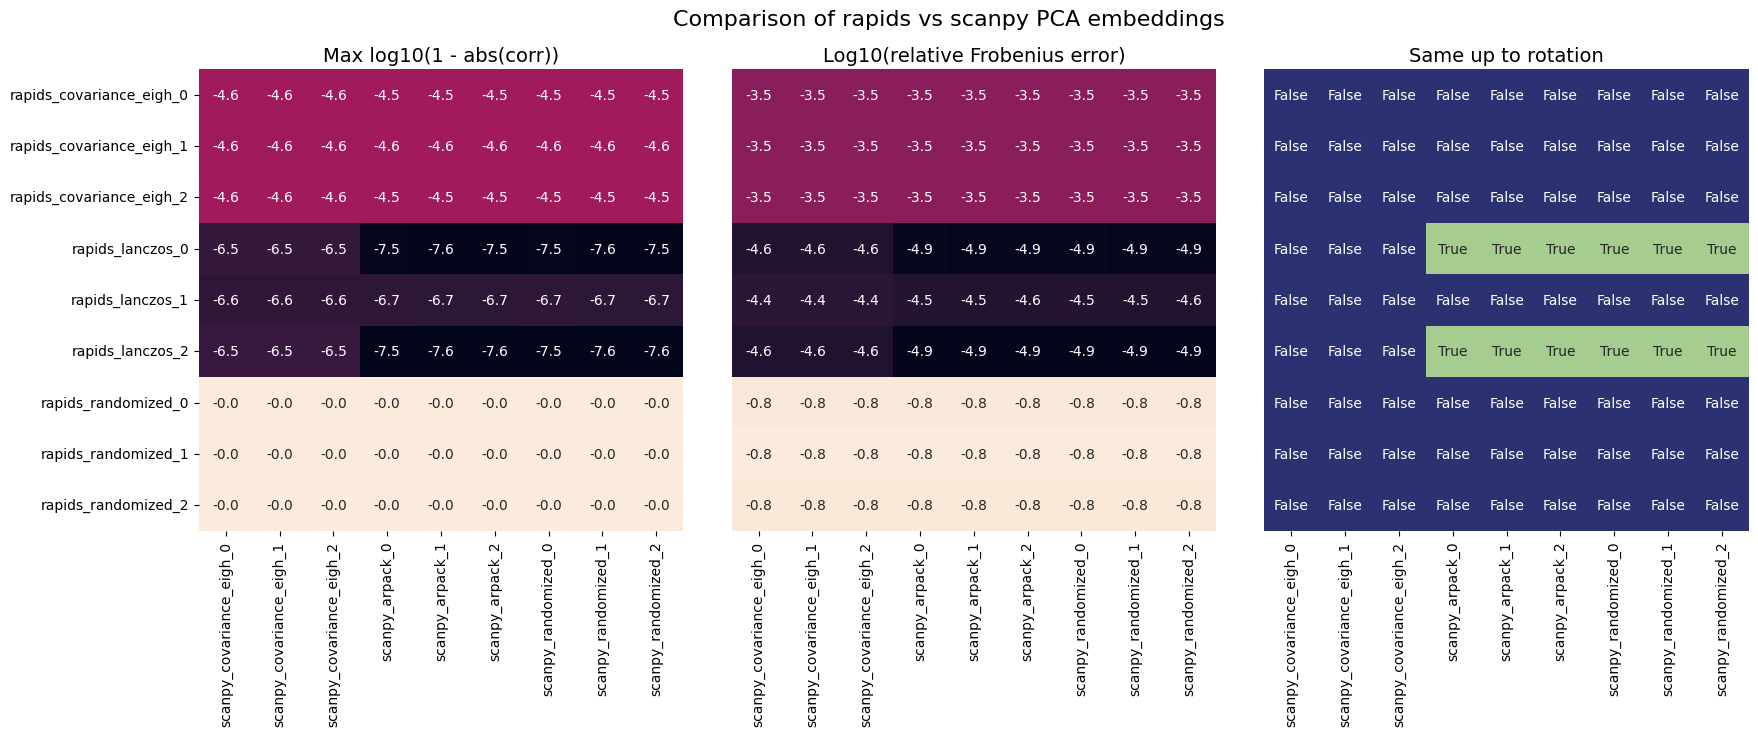

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"wspace": 0.1})

labels_rapids = [ entry.replace("X_pca_", "rapids_") for entry in rapids_entries ]

labels_scanpy = [
    entry.replace("X_pca_", "scanpy_") if entry != "X_pca" else "scanpy_covariance_eigh_0"
    for entry in scanpy_entries
]
sns.heatmap(
    rapids_scanpy_corr_result,
    xticklabels=labels_scanpy,
    yticklabels=labels_rapids,
    annot=True,
    fmt=".1f",
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Max log10(1 - abs(corr))", fontsize=14)

sns.heatmap(
    rapids_scanpy_fro_result,
    xticklabels=labels_scanpy,
    yticklabels="",
    annot=True,
    fmt=".1f",
    cbar=False,
    ax=axes[1],
)
axes[1].set_title("Log10(relative Frobenius error)", fontsize=14)

sns.heatmap(
    rapids_scanpy_same_result,
    xticklabels=labels_scanpy,
    yticklabels="",
    annot=True,
    fmt="",
    ax=axes[2],
    cbar=False,
    cmap="crest_r",
)
axes[2].set_title("Same up to rotation", fontsize=14)
fig.suptitle("Comparison of rapids vs scanpy PCA embeddings", fontsize=16)

## KNN 

In [18]:
adata_scanpy

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden_igraph', 'leiden_leidenalg'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_pca_arpack_0', 'X_pca_arpack_1', 'X_pca_arpack_2', 'X_pca_covariance_eigh_0', 'X_pca_covariance_eigh_1', 'X_pca_covariance_eigh_2', 'X_pca_randomized_0', 'X_pca_randomized_1', 'X_pca_randomized_2', 'hvg', 'leiden_igraph', 'leiden_igraph_colors', 'leiden_leidenalg', 'leiden_leidenalg_colo

Let's start with comparison of `scanpy`'s KNN graphs that were generated with different random states

In [19]:
adata_scanpy.obsp["neighbors0_sklearn_distances"][0, :].nonzero()[1]

array([9332, 8442, 4201, 3511, 2301,  874, 8287, 4982, 7060, 4339, 3386,
       2125, 1354, 5118], dtype=int32)

In [20]:
adata_scanpy.obsp["neighbors0_pynndescent_distances"][0, :].nonzero()[1]

array([9332, 8442, 4201, 3511, 2301,  874, 8287, 4982, 7060, 4339, 2125,
       1354, 5118, 3251], dtype=int32)

In [21]:
entries_scanpy = [
    "neighbors0_pynndescent_distances",
    "neighbors1_pynndescent_distances",
    "neighbors2_pynndescent_distances",
    "neighbors0_sklearn_distances",
    "neighbors1_sklearn_distances",
    "neighbors2_sklearn_distances"
]
result = np.zeros((len(entries_scanpy), len(entries_scanpy)))
for i in range(len(entries_scanpy)):
    for j in range(i, len(entries_scanpy)):
        x_l, y_l = adata_scanpy.obsp[entries_scanpy[i]].nonzero()
        x_r, y_r = adata_scanpy.obsp[entries_scanpy[j]].nonzero()
        match_frac = (np.array(y_l) == np.array(y_r)).sum() / x_l.size
        result[i, j] = match_frac
        result[j, i] = match_frac

Text(0.5, 1.0, 'Fraction of matching neighbors between different random states for Scanpy')

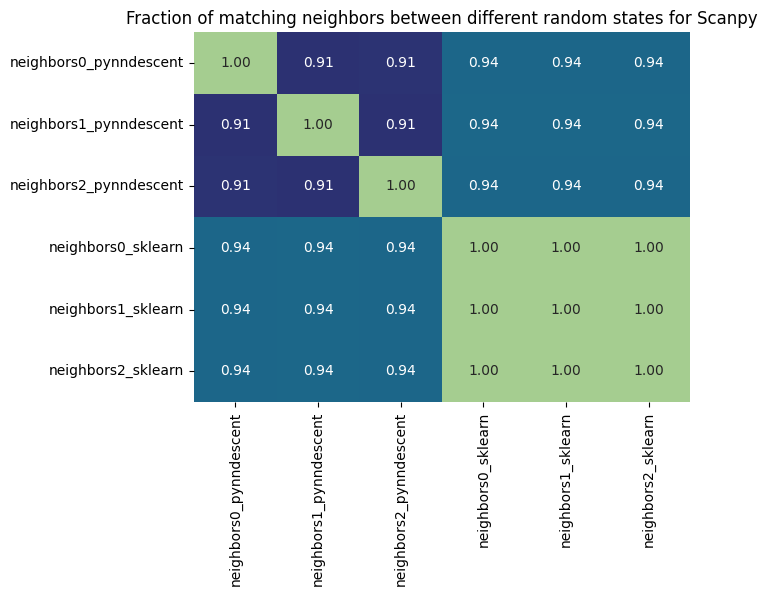

In [22]:
labels_scanpy= [entry.replace("_distances", "") for entry in entries_scanpy]
ax = sns.heatmap(
    result,
    xticklabels=labels_scanpy,
    yticklabels=labels_scanpy,
    annot=True,
    fmt=".2f",
    cbar=False,
    cmap="crest_r",
)
ax.set_title("Fraction of matching neighbors between different random states for Scanpy", fontsize=12)

Let's do the same for `single-cell-rapids` KNN graphs

In [23]:
entries_rapids = [
    "neighbors0_brute_distances",
    "neighbors1_brute_distances",
    "neighbors2_brute_distances",
    "neighbors0_cagra_distances",
    "neighbors1_cagra_distances",
    "neighbors2_cagra_distances",
    "neighbors0_nn_descent_distances",
    "neighbors1_nn_descent_distances",
    "neighbors2_nn_descent_distances",
    "neighbors0_ivfflat_distances",
    "neighbors1_ivfflat_distances",
    "neighbors2_ivfflat_distances",
    "neighbors0_ivfpq_distances",
    "neighbors1_ivfpq_distances",
    "neighbors2_ivfpq_distances",
    "neighbors0_all_neighbors_distances",
    "neighbors1_all_neighbors_distances",
    "neighbors2_all_neighbors_distances",
]

In [24]:
result = np.zeros((len(entries_rapids), len(entries_rapids)))
for i in range(len(entries_rapids)):
    for j in range(i, len(entries_rapids)):
        x_l, y_l = adata_rapids.obsp[entries_rapids[i]].nonzero()
        x_r, y_r = adata_rapids.obsp[entries_rapids[j]].nonzero()
        match_frac = (np.array(y_l) == np.array(y_r)).sum() / x_l.size
        result[i, j] = match_frac
        result[j, i] = match_frac

Text(0.5, 1.0, 'Fraction of matching neighbors between different random states for Rapids')

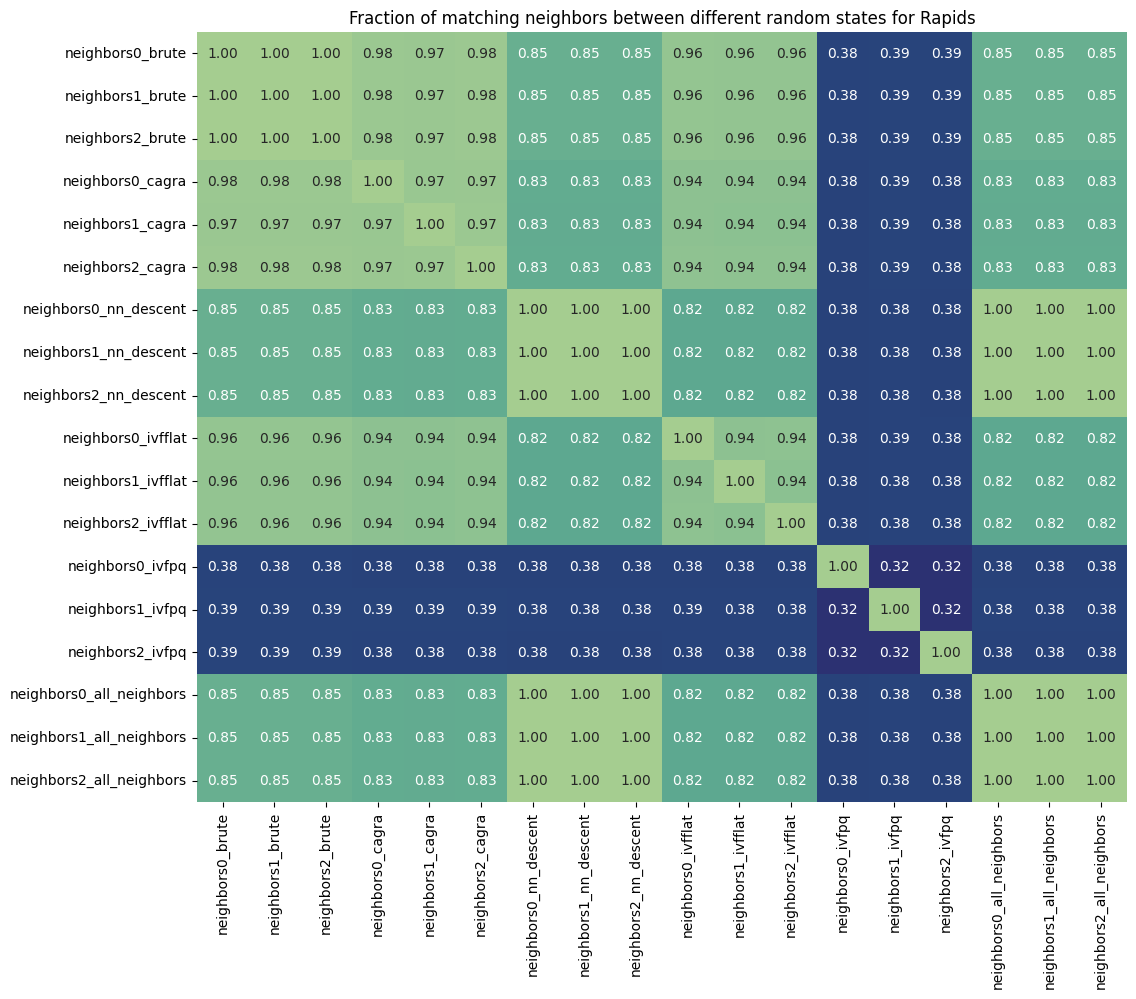

In [25]:
fig, ax = plt.subplots(figsize=(12, 10))

labels_rapids = [entry.replace("_distances", "") for entry in entries_rapids]
sns.heatmap(
    result,
    xticklabels=labels_rapids,
    yticklabels=labels_rapids,
    annot=True,
    fmt=".2f",
    cbar=False,
    cmap="crest_r",
    ax=ax
)
ax.set_title("Fraction of matching neighbors between different random states for Rapids", fontsize=12)

Finally, let's compare KNN graphs from `single-cell-rapids` and `scanpy` directly

In [26]:
result = np.zeros((len(entries_scanpy), len(entries_rapids)))
for i in range(len(entries_scanpy)):
    for j in range(len(entries_rapids)):
        x_l, y_l = adata_scanpy.obsp[entries_scanpy[i]].nonzero()
        x_r, y_r = adata_rapids.obsp[entries_rapids[j]].nonzero()
        match_frac = (np.array(y_l) == np.array(y_r)).sum() / x_l.size
        result[i, j] = match_frac

Text(0.5, 1.0, 'Fraction of matching neighbors between Scanpy (rows) and Rapids (columns)')

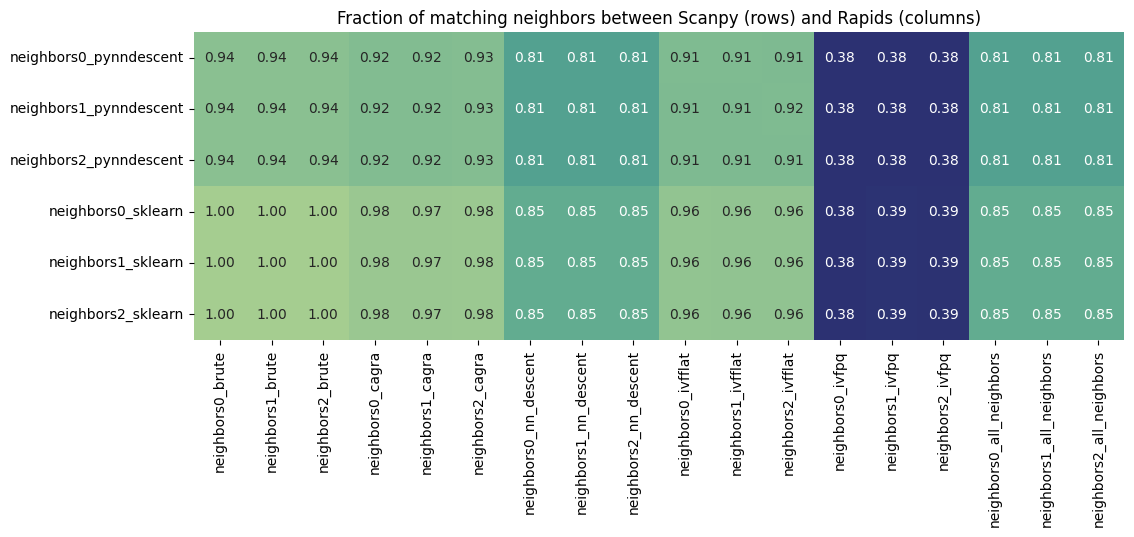

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    result,
    xticklabels=labels_rapids,
    yticklabels=labels_scanpy,
    annot=True,
    fmt=".2f",
    cbar=False,
    cmap="crest_r",
    ax=ax,
)
ax.set_title(
    "Fraction of matching neighbors between Scanpy (rows) and Rapids (columns)",
    fontsize=12,
)

## Leiden

In [28]:
import pandas as pd
import plotly.graph_objects as go


def sankey_two_clusterings(cluster_a, cluster_b, title="Clustering A → Clustering B"):
    """
    cluster_a, cluster_b: 1D arrays/Series of same length (one label per cell)
    """
    a = "cluster" + pd.Series(cluster_a, name="A").astype(str)
    b = "cluster" + pd.Series(cluster_b, name="B").astype(str)

    edges = pd.crosstab(a, b).stack().reset_index(name="count")
    edges = edges[edges["count"] > 0]

    left_nodes = sorted([f"A: {x}" for x in edges["A"].unique()])
    right_nodes = sorted([f"B: {x}" for x in edges["B"].unique()])
    nodes = left_nodes + right_nodes
    node_index = {name: i for i, name in enumerate(nodes)}

    sources = [node_index[f"A: {x}"] for x in edges["A"]]
    targets = [node_index[f"B: {x}"] for x in edges["B"]]
    values = edges["count"].tolist()

    # Create node colors (use plotly colors)
    import plotly.express as px

    colors = px.colors.qualitative.Plotly
    node_colors = [colors[i % len(colors)] for i in range(len(nodes))]

    # Set link colors to match source node colors (with slight transparency)
    link_colors = [
        node_colors[source].replace("rgb", "rgba").replace(")", ", 0.5)")
        for source in sources
    ]

    fig = go.Figure(
        data=[
            go.Sankey(
                node=dict(label=nodes, color=node_colors, pad=15, thickness=18),
                link=dict(
                    source=sources, target=targets, value=values, color=link_colors
                ),
            )
        ]
    )
    fig.update_layout(title_text=title, font_size=12)
    return fig


# Example:
# fig = sankey_two_clusterings(adata.obs["leiden"], adata.obs["louvain"])
# fig.show()

In [29]:
fig = sankey_two_clusterings(
    adata_scanpy.obs["leiden_igraph"], adata_scanpy.obs["leiden_leidenalg"],
    title="Leiden (igraph) → Leiden (leidenalg)"
)
fig.show()

![Scanpy Sankey plot](../figures/sankey_scanpy.png)

In [30]:
fig = sankey_two_clusterings(
    adata_scanpy.obs["leiden_igraph"],
    adata_rapids.obs["leiden"],
    title="Leiden (igraph) → Leiden (rapids)",
)
fig.show()

![Scanpy Sankey plot](../figures/sankey_rapids.png)

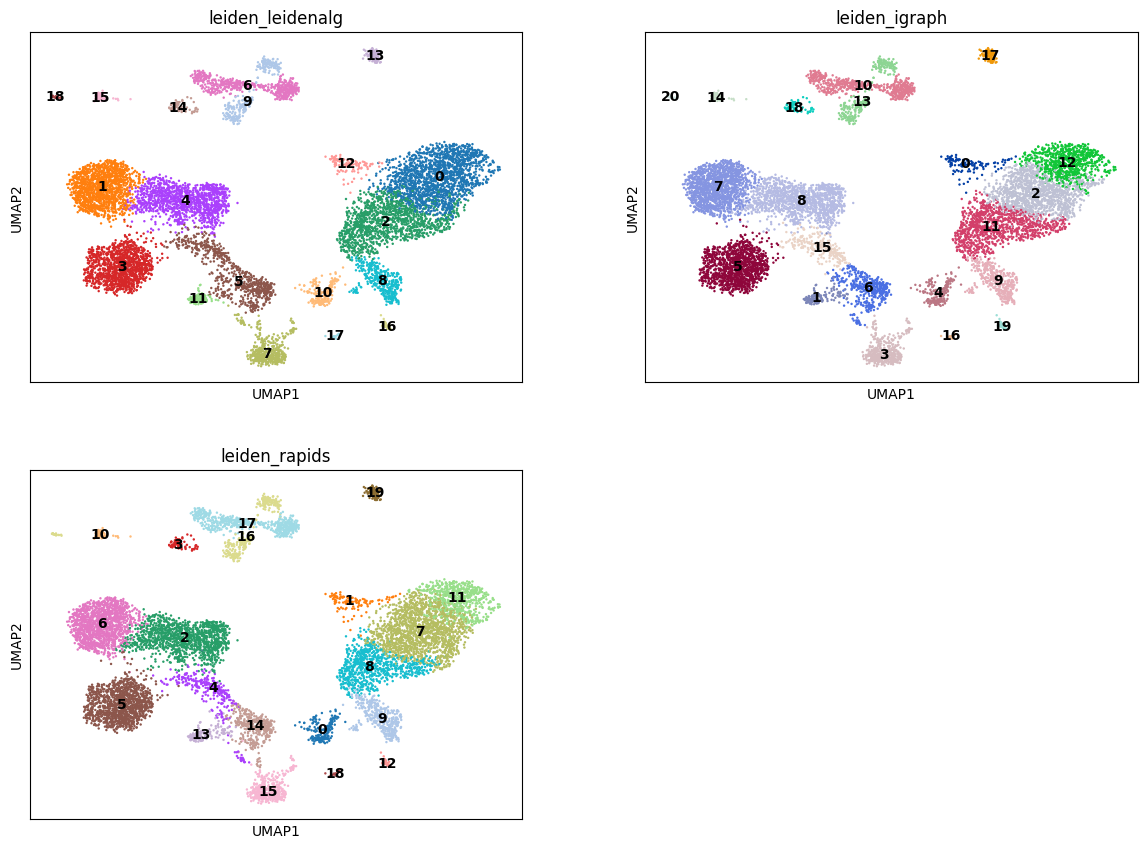

In [31]:
adata_scanpy.obs["leiden_rapids"] = adata_rapids.obs["leiden"].values
sc.pl.umap(
    adata_scanpy, color=["leiden_leidenalg", "leiden_igraph", "leiden_rapids"], legend_loc="on data", ncols=2
)

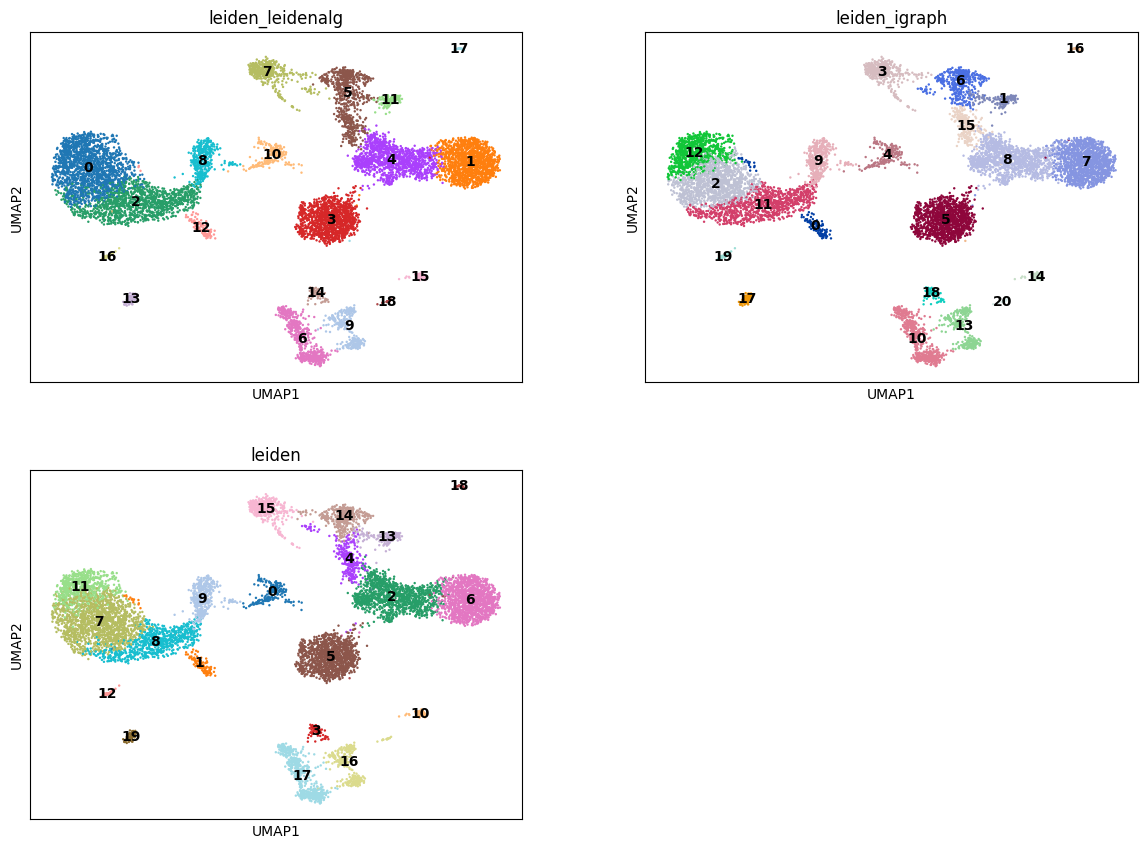

In [32]:
adata_rapids.obs["leiden_leidenalg"] = adata_scanpy.obs["leiden_leidenalg"].values
adata_rapids.obs["leiden_igraph"] = adata_scanpy.obs["leiden_igraph"].values
sc.pl.umap(
    adata_rapids,
    color=["leiden_leidenalg", "leiden_igraph", "leiden"],
    legend_loc="on data",
    ncols=2,
)